In [10]:
import os
import tensorflow as tf
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import time

# Import Keras phục vụ huấn luyện
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tv_C_model import build_model_v1, build_model_v2
from tensorflow.keras.callbacks import  ModelCheckpoint

" cấu hình chung "
EPOCHS = 50
BATCH_SIZE = 32
SEED = 42


In [5]:
# 1. Đọc dữ liệu từ thư mục 'data/' của Thành viên B
images = np.load("images.npy")
labels = np.load("labels.npy")
class_names = np.load("class_names.npy")

print(f"Tổng số mẫu ảnh: {images.shape[0]}")

# 2. One-hot encoding nhãn
num_classes = len(class_names)
X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels, test_size=0.15, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)

# Bước 3.2: Từ 85% còn lại, tách tiếp ra tập Train (70% tổng) và Validation (15% tổng)
# Tỷ lệ tách tập Val từ tập Temp: 15 / 85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)
print(f"Tập Train: {X_train.shape} | Tập Validation: {X_val.shape} | Tập Test: {X_test.shape}")

Tổng số mẫu ảnh: 400
Tập Train: (279, 4096) | Tập Validation: (61, 4096) | Tập Test: (60, 4096)


In [11]:
os.makedirs("models", exist_ok=True)
def make_callbacks(model_path):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=model_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

def train_model(build_fn, model_name, model_path, input_shape, num_classes,
                 X_train, y_train_cat, X_val, y_val_cat,
                 epochs=EPOCHS, batch_size=BATCH_SIZE):
    """
    Xây dựng và huấn luyện 1 model, trả về (model, history).

    Model tốt nhất (theo val_loss) đã được ModelCheckpoint tự lưu
    vào model_path trong quá trình train — không cần save() lại.
    """
    print(f"\n>>> BẮT ĐẦU HUẤN LUYỆN {model_name}...")

    tf.keras.utils.set_random_seed(SEED)  # đảm bảo so sánh công bằng giữa các model

    model = build_fn(input_shape=input_shape, num_classes=num_classes)

    start = time.time()
    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=make_callbacks(model_path),
        verbose=1
    )
    elapsed = time.time() - start
    print(f">>> {model_name} huấn luyện xong sau {elapsed/60:.1f} phút. "
          f"Model tốt nhất đã lưu tại: {model_path}")

    return model, history


# ---- Chạy training cho từng model ----
input_shape = (images.shape[1],)

model_v1, history_v1 = train_model(
    build_model_v1, "MODEL V1 (ReLU)", "models/model_v1_relu.h5",
    input_shape, num_classes, X_train, y_train_cat, X_val, y_val_cat
)

model_v2, history_v2 = train_model(
    build_model_v2, "MODEL V2 (Sigmoid)", "models/model_v2_sigmoid.h5",
    input_shape, num_classes, X_train, y_train_cat, X_val, y_val_cat
)


>>> BẮT ĐẦU HUẤN LUYỆN MODEL V1 (ReLU)...
Epoch 1/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2812 - loss: 1.4097
Epoch 1: val_loss improved from None to 1.48933, saving model to models/model_v1_relu.h5



Epoch 1: finished saving model to models/model_v1_relu.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.2366 - loss: 1.8314 - val_accuracy: 0.3115 - val_loss: 1.4893
Epoch 2/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4062 - loss: 1.4052
Epoch 2: val_loss improved from 1.48933 to 1.28251, saving model to models/model_v1_relu.h5



Epoch 2: finished saving model to models/model_v1_relu.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3692 - loss: 1.4731 - val_accuracy: 0.4262 - val_loss: 1.2825
Epoch 3/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4688 - loss: 1.2306
Epoch 3: val_loss improved from 1.28251 to 1.24253, saving model to models/model_v1_relu.h5



Epoch 3: finished saving model to models/model_v1_relu.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3978 - loss: 1.2679 - val_accuracy: 0.4754 - val_loss: 1.2425
Epoch 4/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4375 - loss: 1.1900
Epoch 4: val_loss did not improve from 1.24253
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5054 - loss: 1.2002 - val_accuracy: 0.4262 - val_loss: 1.2544
Epoch 5/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6250 - loss: 1.1180
Epoch 5: val_loss improved from 1.24253 to 1.22675, saving model to models/model_v1_relu.h5



Epoch 5: finished saving model to models/model_v1_relu.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5842 - loss: 1.1052 - val_accuracy: 0.4754 - val_loss: 1.2268
Epoch 6/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5312 - loss: 1.0673
Epoch 6: val_loss did not improve from 1.22675
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5842 - loss: 1.0378 - val_accuracy: 0.5082 - val_loss: 1.2661
Epoch 7/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6875 - loss: 1.0143
Epoch 7: val_loss did not improve from 1.22675
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6703 - loss: 0.9605 - val_accuracy: 0.4918 - val_loss: 1.2367
Epoch 8/50
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6562 - loss: 0.9352
Epoch 8: val_loss did not improve from 1.22675
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6989 - loss: 0.9067 - val_accuracy: 0.5082 - val_loss: 1.2448
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7191 - loss: 0.8545 
Epoch 9: val

...


Epoch 17: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4910 - loss: 1.2087 - val_accuracy: 0.4918 - val_loss: 1.2226
Epoch 18/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5351 - loss: 1.1808
Epoch 18: val_loss improved from 1.22259 to 1.20861, saving model to models/model_v2_sigmoid.h5



Epoch 18: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5125 - loss: 1.1566 - val_accuracy: 0.5738 - val_loss: 1.2086
Epoch 19/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5208 - loss: 1.1677
Epoch 19: val_loss improved from 1.20861 to 1.18986, saving model to models/model_v2_sigmoid.h5



Epoch 19: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5412 - loss: 1.1307 - val_accuracy: 0.5410 - val_loss: 1.1899
Epoch 20/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4971 - loss: 1.1215
Epoch 20: val_loss did not improve from 1.18986
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5484 - loss: 1.0861 - val_accuracy: 0.5082 - val_loss: 1.1953
Epoch 21/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5545 - loss: 1.0904
Epoch 21: val_loss improved from 1.18986 to 1.18918, saving model to models/model_v2_sigmoid.h5



Epoch 21: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5699 - loss: 1.0689 - val_accuracy: 0.5410 - val_loss: 1.1892
Epoch 22/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4846 - loss: 1.1848
Epoch 22: val_loss did not improve from 1.18918
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5305 - loss: 1.1330 - val_accuracy: 0.5246 - val_loss: 1.1940
Epoch 23/50
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6134 - loss: 1.0465
Epoch 23: val_loss improved from 1.18918 to 1.18585, saving model to models/model_v2_sigmoid.h5



Epoch 23: finished saving model to models/model_v2_sigmoid.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6057 - loss: 0.9990 - val_accuracy: 0.5082 - val_loss: 1.1858
Epoch 24/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6647 - loss: 1.0043
Epoch 24: val_loss did not improve from 1.18585
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6559 - loss: 1.0026 - val_accuracy: 0.5246 - val_loss: 1.1866
Epoch 25/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6202 - loss: 0.9473
Epoch 25: val_loss did not improve from 1.18585
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5950 - loss: 0.9647 - val_accuracy: 0.4918 - val_loss: 1.1879
Epoch 26/50
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6327 - loss: 0.9381
Epoch 26: val_loss did not improve from 1.18585
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6344 - loss: 0.9022 - val_accuracy: 0.5082 - val_loss: 1.1923
Epoch 27/50
5/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7458 - loss: 0.8840
E

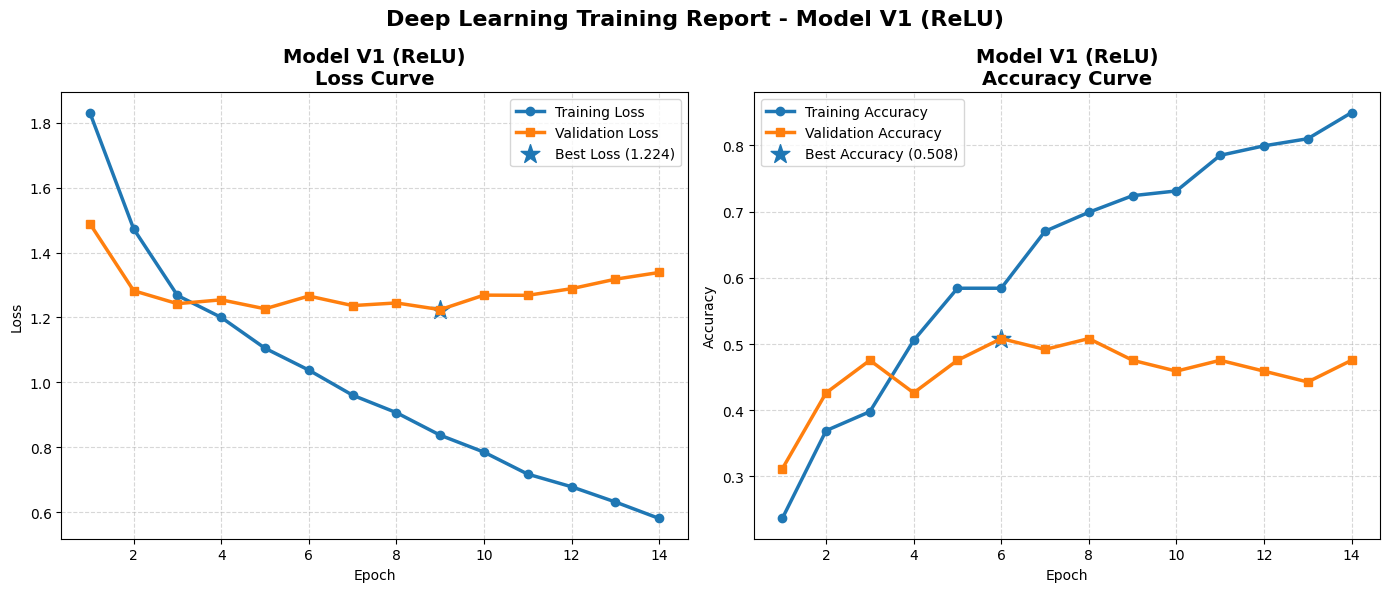


Model V1 (ReLU)
Best Validation Accuracy : 0.5082
Best Validation Loss     : 1.2242
Best Accuracy Epoch      : 6
Best Loss Epoch          : 9


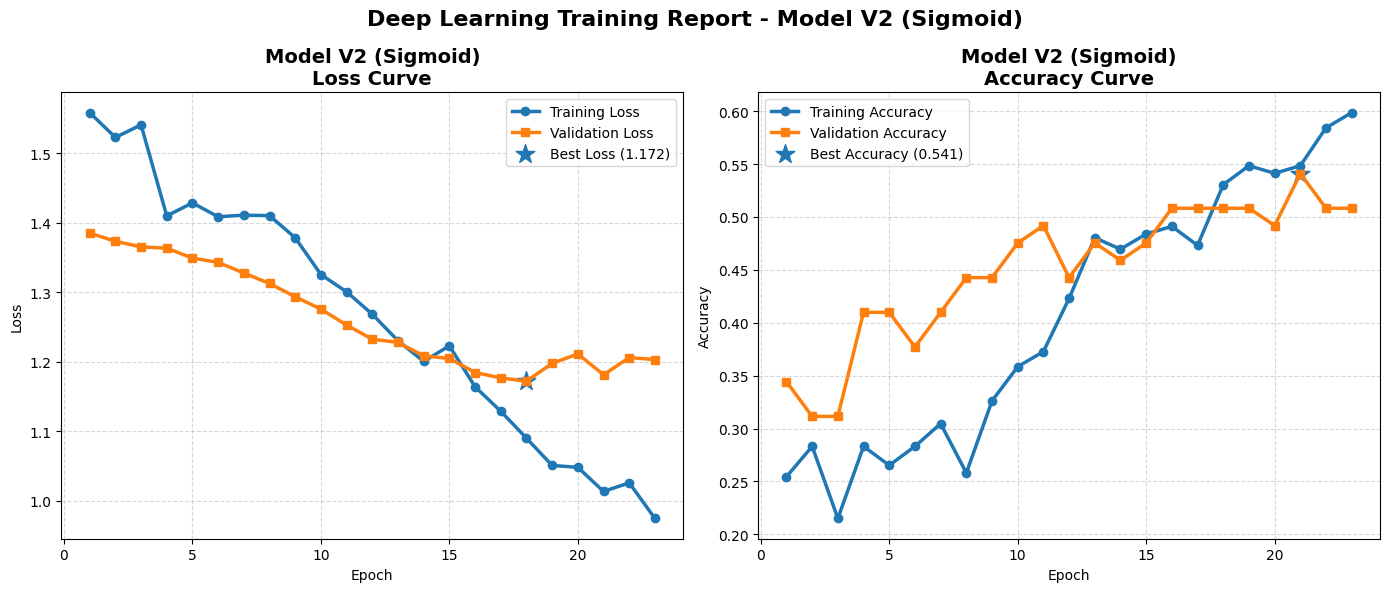


Model V2 (Sigmoid)
Best Validation Accuracy : 0.5410
Best Validation Loss     : 1.1721
Best Accuracy Epoch      : 21
Best Loss Epoch          : 18


In [7]:
def _plot_metric_subplot(ax, epochs, train_vals, val_vals, metric_name,
                          best_epoch, best_value, title):
    ax.plot(epochs, train_vals, marker='o', linewidth=2.5, label=f'Training {metric_name}')
    ax.plot(epochs, val_vals, marker='s', linewidth=2.5, label=f'Validation {metric_name}')
    ax.scatter(best_epoch, best_value, s=200, marker='*',
               label=f'Best {metric_name} ({best_value:.3f})')
    ax.set_title(f'{title}\n{metric_name} Curve', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric_name)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()


def plot_learning_curves(history, title, filename, output_dir="data", dpi=300, show=True):
    """
    Vẽ và lưu biểu đồ Loss & Accuracy từ Keras history.

    Parameters
    ----------
    history : keras.callbacks.History
        Object trả về từ model.fit(), phải có .history chứa
        'loss', 'val_loss', 'accuracy', 'val_accuracy'.
    title : str
        Tiêu đề hiển thị trên biểu đồ.
    filename : str
        Tên file ảnh khi lưu (vd: 'learning_curve_v1.png').
    output_dir : str
        Thư mục lưu ảnh (mặc định 'data').
    dpi : int
        Độ phân giải khi lưu ảnh.
    show : bool
        Có gọi plt.show() hay không (tắt khi chạy hàng loạt/script).
    """
    h = history.history
    required = ['loss', 'val_loss', 'accuracy', 'val_accuracy']
    missing = [k for k in required if k not in h]
    if missing:
        raise KeyError(f"history thiếu các key: {missing}")

    train_loss, val_loss = h['loss'], h['val_loss']
    train_acc, val_acc = h['accuracy'], h['val_accuracy']
    epochs = np.arange(1, len(train_loss) + 1)

    best_acc_epoch = int(np.argmax(val_acc)) + 1
    best_loss_epoch = int(np.argmin(val_loss)) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    _plot_metric_subplot(ax1, epochs, train_loss, val_loss, 'Loss',
                          best_loss_epoch, val_loss[best_loss_epoch - 1], title)
    _plot_metric_subplot(ax2, epochs, train_acc, val_acc, 'Accuracy',
                          best_acc_epoch, val_acc[best_acc_epoch - 1], title)

    fig.suptitle(f'Deep Learning Training Report - {title}', fontsize=16, fontweight='bold')
    fig.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight')

    if show:
        plt.show()
    plt.close(fig)

    print("\n" + "=" * 60)
    print(f"{title}")
    print("=" * 60)
    print(f"Best Validation Accuracy : {max(val_acc):.4f}")
    print(f"Best Validation Loss     : {min(val_loss):.4f}")
    print(f"Best Accuracy Epoch      : {best_acc_epoch}")
    print(f"Best Loss Epoch          : {best_loss_epoch}")


# Thực hiện vẽ và lưu biểu đồ cho cả 2 model
plot_learning_curves(history_v1, "Model V1 (ReLU)", "learning_curve_v1.png")
plot_learning_curves(history_v2, "Model V2 (Sigmoid)", "learning_curve_v2.png")


 ĐÁNH GIÁ MÔ HÌNH: Model V1 ReLU 

              precision    recall  f1-score   support

         Bus       0.20      0.07      0.10        15
         Car       0.33      0.33      0.33        15
       Truck       0.35      0.73      0.48        15
  motorcycle       0.33      0.20      0.25        15

    accuracy                           0.33        60
   macro avg       0.31      0.33      0.29        60
weighted avg       0.31      0.33      0.29        60



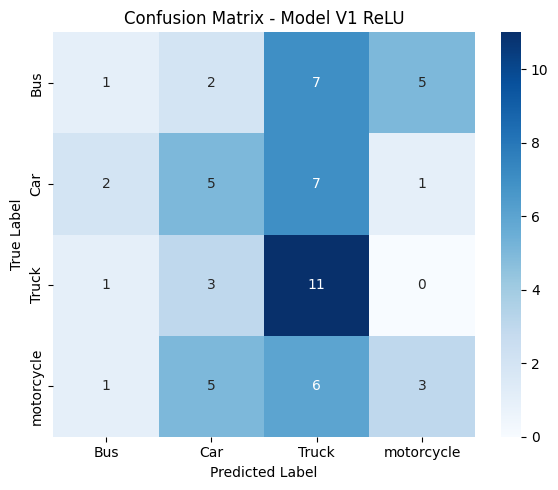


 ĐÁNH GIÁ MÔ HÌNH: Model V2 Sigmoid 

              precision    recall  f1-score   support

         Bus       0.38      0.40      0.39        15
         Car       0.44      0.47      0.45        15
       Truck       0.47      0.47      0.47        15
  motorcycle       0.46      0.40      0.43        15

    accuracy                           0.43        60
   macro avg       0.44      0.43      0.43        60
weighted avg       0.44      0.43      0.43        60



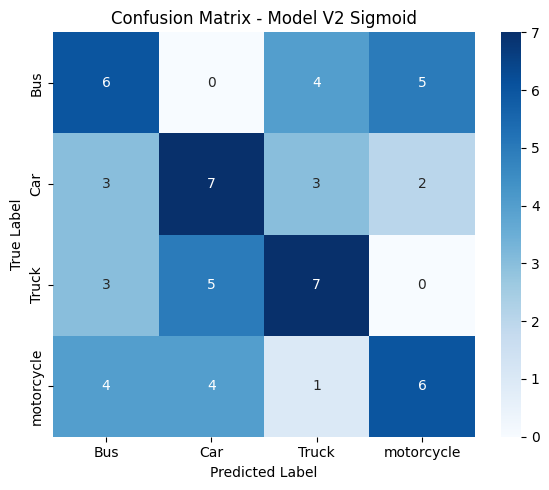

In [11]:
def evaluate_model(model, title):
    print(f"\n ĐÁNH GIÁ MÔ HÌNH: {title} \n")

    # Dự đoán trên tập Test
    predictions = model.predict(X_test, verbose=0)

    # Chuyển xác suất thành nhãn dự đoán
    y_pred = np.argmax(predictions, axis=1)

    # y_test đã là nhãn số nên KHÔNG dùng argmax
    y_true = y_test

    # In Classification Report
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    # Tạo Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Vẽ Confusion Matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    # Lưu hình
    plt.savefig(
        f"data/confusion_matrix_{title.lower().replace(' ', '_')}.png",
        dpi=120
    )

    plt.show()


# Đánh giá hai mô hình
evaluate_model(model_v1, "Model V1 ReLU")
evaluate_model(model_v2, "Model V2 Sigmoid")